# MTY4-A1C: Lattice Gas Sample Solutions
by Sergio Eraso\
Activity based on the course by [Bryan Clark](https://courses.physics.illinois.edu/phys498cmp/sp2022/CellularAutomata/CellularAutomata.html)

We will work with a simplified model of gas particles diffusing on a lattice. You are already familiar with diffusion from your random walks simulations. Our main goal in this occasion is to animate how the system evolves over time and to measure one of the central concepts in statistical physics: **entropy**.

The general formula for the entropy of a discrete set of outcomes with probabilities $p_i$ is

$$
    S[p_i] = -\sum_i p_i \log p_i
$$  (my_label)

In the case of a fair coin, fair die, or any other uniform distribution with $\Omega$ equiprobable outcomes, this formula reduces to the familiar equation from class,

$$S = \log \Omega $$

To explore the connection between entropy and information, instead of directly using these formulas, we will also quantify the entropy by measuring the compressibility of an image of the lattice gas.

In [1]:
# ─── ensure the project root (one level up) is on Python's import path so we can use the helper functions ───
import sys, os
repo_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# now imports will find simulation_functions
import simulation_functions.lattice_gas_functions as sols
import numpy as np
import matplotlib.pyplot as plt

## Simulation

In this lattice gas automaton, we use two colors: black (1) and white (0). Black represents gas particles, and white represents empty space.
The system is initialized with the right half of the $L \times L$ lattice (2D array) filled with gas (black), and the left half empty (white).

We update the state of the system as follows:

1. Randomly select a site
2. Randomly select one of its neighbors
3. Swap the contents of the two sites (even if they are the same).
   
The simulation uses **open boundary conditions**, the top and bottom edges do not wrap, whereas the left and right edges do. Care must be taken to avoid accessing out-of-bounds memory. Note that the microscopic laws of this system are **time-reversible** -- a particle is just as likely to go in any given direction as in the opposite direction.

The file *lattice_gas_functions.py* contains everything you need to run the simulation. Feel free to use them if you need some help. Here is a summary of the functions included:
- `initialize_lattice`: initializes a 2D lattice of size $L\times L$
- `choose_neighbor`: chooses a neighbor of given a site (row, col) respecting the boundary conditions
- `update`: completes steps 1-3 as outlined above
- `sweep`: runs `update` $L\times L$ times

Remember that to use these functions you need to use the syntax `sols.function_name`

### Initialization

**[Task]** Write a function `initialize_lattice` that initializes the lattice as described above. *(Hint: You can do this in a couple lines by using `np.ones` and slicing)*

In [2]:
def initialize_lattice(L : int):
    """initialize a lattice of size LxL with half filled with ones and half with zeros

    Args:
        L (int): dimension of the lattice

    Returns:
        ndarray: initialized lattice of size LxL with half filled with ones and half with zeros
    """
    # create the lattice
    lattice = np.ones((L,L))
    lattice[:,:L//2] = 0
    
    return lattice

**[Task]** Plot an initialized lattice with $L = 50$ to make sure your above code works as intended.

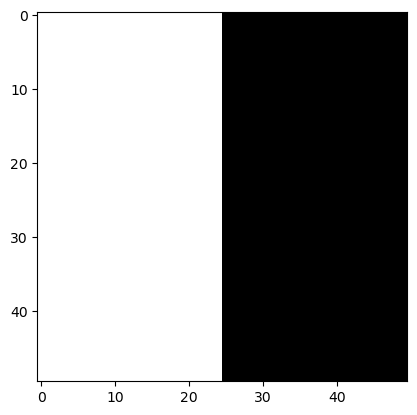

In [9]:
init_test = initialize_lattice(50)
fig, ax = plt.subplots()
ax.imshow(init_test, cmap="grey_r")

### Simulation Step

**[Task]** Write some code that chooses random coordinates of an $L\times L$ lattice

In [11]:
# random coordinates of a lattice
L = 10
row = np.random.randint(0,L)
col = np.random.randint(0,L)

**[Task]** We will now write a function that advances the simulation by one step (one update). Feel free to use `sols.choose_neighbor` so that you don't have to bother implementing the boundary conditions (this can be a little tedious). For an extra challenge, implement this function yourself. 

In [3]:
def update(lattice):
    """evolves the lattice by randomly selecting a site and swapping it with one of its neighbors

    Args:
        lattice (ndarray): current state of the lattice

    Returns:
        ndarray: new state of the lattice after one update
    """
    # step 1: chose a random site of the lattice
    L = lattice.shape[0]
    row = np.random.randint(0,L)
    col = np.random.randint(0,L)

    # step 2: use the choose_neighbor function to randomly select one of the neighbors of the chosen site
    # choose_neighbor returns the (row,col) coordinates of the chosen neighbor
    n_row, n_col = sols.choose_neighbor(row, col, L)

    # step 3: swap the values of the central site with the chosen neighbor
    # store the current values of the central site and the neighbor into new variables
    site = lattice[row,col]
    neighbor = lattice[n_row, n_col]

    # use the variables defined above to swap the current site with the neighbor in the lattice
    lattice[row][col] = neighbor
    lattice[n_row][n_col] = site
    
    return lattice

**[Task]** Now write a function called `sweep` that loops over `update` $L\times L$ times. This will be the fundamental time unit of our simulation. Why do we do this?

In [4]:
def sweep(lattice):
    """performs a sweep over the lattice, that is LxL updates
    
    Args:
        lattice (ndarray): current state of the lattice
        
    Returns:
        ndarray: new state of the lattice after LxL updates
    """
    # we have to create a copy of the given lattice before updating it
    # try deleting .copy() if you want to see what goes wrong if we don't include this
    new_lattice = lattice.copy()
    
    # update the lattice LxL times
    L = lattice.shape[0]
    for _ in range(L*L):
        new_latice = update(new_lattice)
    return new_lattice

**[Optional]** There's this nice package `tqdm` that lets you quickly create progress bars for longer simulations to let you see how long they will take. When running your `for` loop, instead of `range` use the function `trange` imported from `tqdm.notebook`.

In [5]:
from tqdm.notebook import trange

Run your lattice gas simulation for a system of size $75\times 75$ for $1000$ sweeps. Save snapshots of your lattice gas simulation every sweep.

In [7]:
L = 75  # size of the lattice
lattice = initialize_lattice(L)
snapshots = []
snapshots.append(lattice)
n_sweeps = 1000  # number of sweeps to perform
for i in trange(n_sweeps):
    lattice = sweep(lattice)
    snapshots.append(lattice)

  0%|          | 0/1000 [00:00<?, ?it/s]

## Measurements

### Producing the Animation
We create a movie of our system using what we've learned. If you need to review animations, look at *NB02 Data Visualization*.

In [8]:
# set up the notebook to display animations
from matplotlib import animation, rcParams
from IPython.display import HTML
from imageio_ffmpeg import get_ffmpeg_exe   # this is used to display the animation in the notebook
rcParams['animation.ffmpeg_path'] = get_ffmpeg_exe()

**[Task]** Let's create an animation using every 5th snapshot -- otherwise the animation file is too large. Save your animation frames in an array named `animation_frames`. Inside of the update function, instead of using the `set_data` function you will use the `set_array` function.

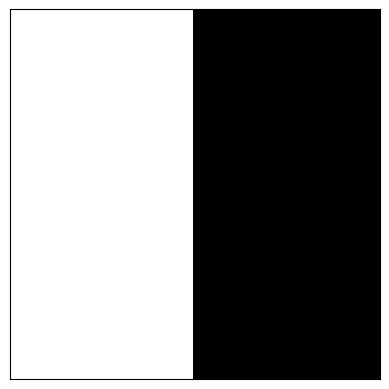

In [9]:
# only use every 5th snapshot for the animation frames
animation_frames = snapshots[::5]

# create the first frame of the animation
fig, ax = plt.subplots()
im = ax.imshow(animation_frames[0], cmap='gray_r')

ax.set_xticks([]) # remove x ticks
ax.set_yticks([]) # remove y ticks
# write update function
def update_frame(n):
    im.set_array(animation_frames[n])# use set_array to update the data
    return im,     # have to unpack when we return

In [10]:
# create the animation and display it in the notebook
anim = animation.FuncAnimation(fig, func=update_frame, frames=len(animation_frames), interval=50, blit=True)
HTML(anim.to_jshtml())

### Image Compression as an Estimate for Entropy

We have seen that **entropy is a measure of how much information you must provide to fully specify the microstate of your system**. For instance, if I toss 100 coins and I obtain a sequence of exactly 50 heads followed by 50 tails, I can very easily summarize this sequence with a sentence: "the first half is heads, the second half is tails". However, if I obtain a much less ordered sequence such as `[H,H,T,T,H,T,H,H,...]`, then I can't write down a simple sentence to fully specify the microstate of the system -- it requires more information to specify and therefore has a higher entropy. 

The second law of thermodynamics states that nature tends to evolve towards states of higher entropy. We will use an image compression tool to calculate the size in bits of each one of our snapshot images after compression -- analogous to our attempts at coming up with short descriptions of our microstate in the context of coin sequences.

In [11]:
import gzip    # image compression package
from sys import getsizeof   # function to get size of image

**[Task]** To compress a snapshot call `gzip.compress(snap.tobytes())`. This will return a string that looks like nonsense. To make some sense of it, calculate the size of this information by passing the result into `getsizeof`. Save the size of each compressed snapshot.

In [12]:
# calculate the size of each compressed snapshot, store this into an array
sizes = []
for snap in snapshots:
    compressed_lattice = gzip.compress(snap.tobytes())
    size = getsizeof(compressed_lattice)
    sizes.append(size)

**[Task]** Finally, plot the size of the compressed image as time progresses. Think about the following:
- What do you observe? 
- Can you explain this in terms of microstates, macrostates, and entropy?
- Do you expect the long-term behavior of your simulation to depend on the specific initialization?

Text(0, 0.5, 'Compressed Size (bytes)')

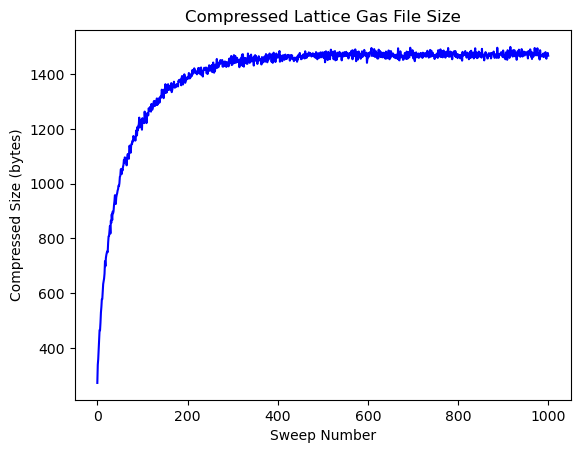

In [14]:
# plot of compressed image size
fig, ax = plt.subplots()
ax.plot(sizes, color='blue')
ax.set_title("Compressed Lattice Gas File Size")
ax.set_xlabel("Sweep Number")
ax.set_ylabel("Compressed Size (bytes)")

### Entropy of 1D Projection

We will now directly calculate the entropy. The first step is to choose what our macrostates are--to choose some coarse-graining procedure. For this calculation, we will use the density of the gas along the $x$ direction as our macrostate. For example, this $5\times5$ configuration gets coarse-grained as follows,

<center><img src="../images/gas_coarse.png" width="200" /></center>

**[Task]** Write a function `x_density` that takes in a lattice and returns a 1D array of the density of gas at each column. *(Hint: you can accomplish this in one line using `np.mean` and the `axis` keyword argument)*.

**[Optional]** Include a parameter `window_size` that smooths out the density profile by averaging over multiple columns

In [136]:
def x_density(lattice, window_size : int = 1):
    """returns x density of a given lattice gas configuration

    Args:
        lattice (NDArray): current state
        
    Returns:
        NDArray : x density profile
    """
    L = lattice.shape[0]
    # density of each column
    dens = np.mean(lattice, axis = 0)
    # concatenate the array three times for periodic boundary conditions
    dens3 = np.concatenate([dens,dens,dens])
    window = np.ones(window_size)/window_size
    # calculate the rolling average density for each x location
    dens = np.convolve(window, dens3, mode="same")[L:2*L]
    return dens

How many microstates--exact configurations of gas particles on the lattice--correspond to the macrostate of the initial configuration? 

**[Task]** Calculate the density profile of each one of your snapshots. Create an animation of the evolution of the density profile.

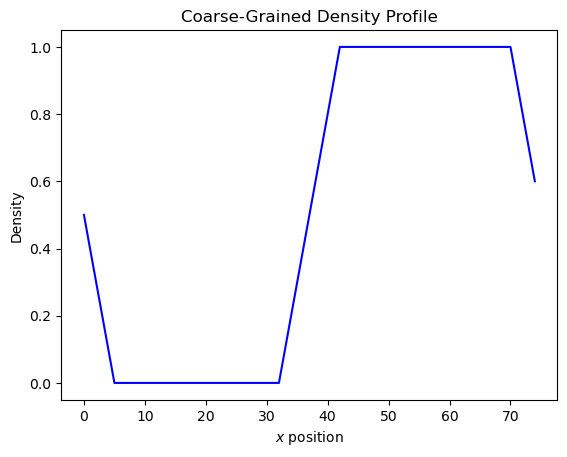

In [149]:
L = snapshots[0].shape[0]
x_vals = np.arange(L)
fig, ax = plt.subplots()
densities = [x_density(snap, 10) for snap in snapshots]
dens_frames = densities[::5]
dens_plot, = ax.plot(x_vals, dens_frames[0], color="blue")
ax.set_title("Coarse-Grained Density Profile")
ax.set_xlabel(r"$x$ position")
ax.set_ylabel("Density")
def update_dens(n):
    dens_plot.set_data(x_vals, dens_frames[n])
    return dens_plot,

In [150]:
dens_anim = animation.FuncAnimation(fig, func=update_dens, frames=len(dens_frames), interval=50, blit=True)
HTML(dens_anim.to_jshtml())

We can see that the density profile approaches a uniform distribution--the gas distributes itself evenly throughout the room. Let's use that exact formula for the entropy we introduced at the very beginning of this notebook to calculate the entropy of this density profile as time progresses. We'll use the `entropy` function from the `scipy.stats` module.

In [139]:
from scipy.stats import entropy

**[Task]** Plot the entropy of the density profile as a function of time

Text(0, 0.5, 'Entropy')

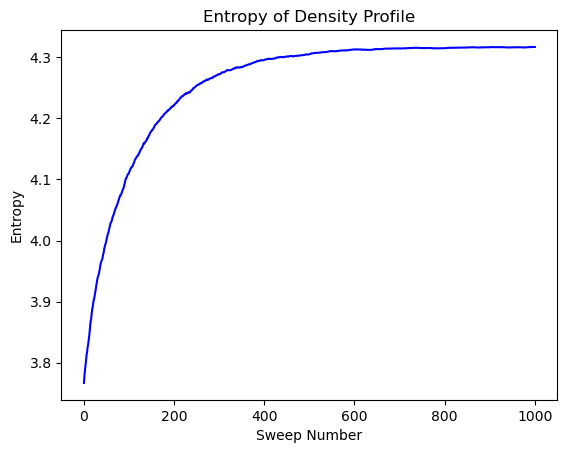

In [144]:
entropies = entropy(densities, axis=1)
fig, ax = plt.subplots()
ax.plot(entropies, color="blue")
ax.set_title("Entropy of Density Profile")
ax.set_xlabel("Sweep Number")
ax.set_ylabel("Entropy")